In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
DATA_DIR = '.'

files = sorted(glob.glob(os.path.join(DATA_DIR, '*.csv')))
print(f"Found {len(files)} files")
for f in files:
    print(os.path.basename(f))

Found 12 files
201801-fordgobike-tripdata.csv
201802-fordgobike-tripdata.csv
201803-fordgobike-tripdata.csv
201804-fordgobike-tripdata.csv
201805-fordgobike-tripdata.csv
201806-fordgobike-tripdata.csv
201807-fordgobike-tripdata.csv
201808-fordgobike-tripdata.csv
201809-fordgobike-tripdata.csv
201810-fordgobike-tripdata.csv
201811-fordgobike-tripdata.csv
201812-fordgobike-tripdata.csv


In [3]:
dfs = [pd.read_csv(f, parse_dates=['start_time', 'end_time']) for f in files]
df = pd.concat(dfs, ignore_index=True)
del dfs

print("Combined shape:", df.shape)

Combined shape: (1863721, 16)


In [4]:
df.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,75284,2018-01-31 22:52:35.239,2018-02-01 19:47:19.824,120.0,Mission Dolores Park,37.761420,-122.426435,285.0,Webster St at O'Farrell St,37.783521,-122.431158,2765,Subscriber,1986.0,Male,No
1,85422,2018-01-31 16:13:34.351,2018-02-01 15:57:17.310,15.0,San Francisco Ferry Building (Harry Bridges Pl...,37.795392,-122.394203,15.0,San Francisco Ferry Building (Harry Bridges Pl...,37.795392,-122.394203,2815,Customer,NaN,NaN,No
2,71576,2018-01-31 14:23:55.889,2018-02-01 10:16:52.116,304.0,Jackson St at 5th St,37.348759,-121.894798,296.0,5th St at Virginia St,37.325998,-121.877120,3039,Customer,1996.0,Male,No
3,61076,2018-01-31 14:53:23.562,2018-02-01 07:51:20.500,75.0,Market St at Franklin St,37.773793,-122.421239,47.0,4th St at Harrison St,37.780955,-122.399749,321,Customer,NaN,NaN,No
4,39966,2018-01-31 19:52:24.667,2018-02-01 06:58:31.053,74.0,Laguna St at Hayes St,37.776435,-122.426244,19.0,Post St at Kearny St,37.788975,-122.403452,617,Subscriber,1991.0,Male,No


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1863721 entries, 0 to 1863720
Data columns (total 16 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   duration_sec             int64         
 1   start_time               datetime64[us]
 2   end_time                 datetime64[us]
 3   start_station_id         float64       
 4   start_station_name       str           
 5   start_station_latitude   float64       
 6   start_station_longitude  float64       
 7   end_station_id           float64       
 8   end_station_name         str           
 9   end_station_latitude     float64       
 10  end_station_longitude    float64       
 11  bike_id                  int64         
 12  user_type                str           
 13  member_birth_year        float64       
 14  member_gender            str           
 15  bike_share_for_all_trip  str           
dtypes: datetime64[us](2), float64(7), int64(2), str(5)
memory usage: 352.3 MB


In [6]:
df.isnull().sum()

duration_sec                    0
start_time                      0
end_time                        0
start_station_id            11771
start_station_name          11771
start_station_latitude          0
start_station_longitude         0
end_station_id              11771
end_station_name            11771
end_station_latitude            0
end_station_longitude           0
bike_id                         0
user_type                       0
member_birth_year          110718
member_gender              110367
bike_share_for_all_trip         0
dtype: int64

In [7]:
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
print(missing_pct[missing_pct > 0])

start_station_id      0.63
start_station_name    0.63
end_station_id        0.63
end_station_name      0.63
member_birth_year     5.94
member_gender         5.92
dtype: float64


In [8]:
before = len(df)
df = df.dropna(subset=['start_station_id', 'end_station_id']).copy()
after = len(df)
print(f"Dropped {before - after} rows ({(before-after)/before*100:.2f}%)")
print("New shape:", df.shape)

Dropped 11771 rows (0.63%)
New shape: (1851950, 16)


In [9]:
df['member_gender'] = df['member_gender'].fillna('Unknown')

print(df['member_gender'].value_counts())

member_gender
Male       1279545
Female      435361
Unknown     110043
Other        27001
Name: count, dtype: int64


In [10]:
df['start_station_id'] = df['start_station_id'].astype(int)
df['end_station_id'] = df['end_station_id'].astype(int)

df.dtypes

duration_sec                        int64
start_time                 datetime64[us]
end_time                   datetime64[us]
start_station_id                    int64
start_station_name                    str
start_station_latitude            float64
start_station_longitude           float64
end_station_id                      int64
end_station_name                      str
end_station_latitude              float64
end_station_longitude             float64
bike_id                             int64
user_type                             str
member_birth_year                 float64
member_gender                         str
bike_share_for_all_trip               str
dtype: object

In [11]:
invalid_duration = (df['duration_sec'] <= 0).sum()
print(f"Trips with zero/negative duration: {invalid_duration}")

Trips with zero/negative duration: 0


In [12]:
df['age'] = 2018 - df['member_birth_year']

print(df['age'].describe())

count    1.741556e+06
mean     3.493921e+01
std      1.045133e+01
min      1.800000e+01
25%      2.700000e+01
50%      3.300000e+01
75%      4.000000e+01
max      1.370000e+02
Name: age, dtype: float64


In [13]:
invalid_age = ((df['age'] > 100) | (df['age'] < 10)).sum()
print(f"Rows with implausible age (>100 or <10): {invalid_age}")

df.loc[(df['age'] > 100) | (df['age'] < 10), 'age'] = np.nan

print(f"Remaining valid age values: {df['age'].notnull().sum()}")

Rows with implausible age (>100 or <10): 1160
Remaining valid age values: 1740396


In [14]:
# Duration ko minutes mein convert karo (zyada readable hai seconds se)
df['duration_min'] = df['duration_sec'] / 60

# start_time se time-based features nikaalo
df['start_month'] = df['start_time'].dt.month
df['start_month_name'] = df['start_time'].dt.month_name()
df['start_hour'] = df['start_time'].dt.hour
df['start_dayofweek'] = df['start_time'].dt.dayofweek   # 0=Monday, 6=Sunday
df['day_type'] = df['start_dayofweek'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

# Month se season banao
def month_to_season(m):
    if m in [12, 1, 2]:
        return 'Winter'
    elif m in [3, 4, 5]:
        return 'Spring'
    elif m in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['season'] = df['start_month'].apply(month_to_season)

df[['duration_min', 'start_month_name', 'start_hour', 'day_type', 'season']].head()

,duration_min,start_month_name,start_hour,day_type,season
0,1254.733333,January,22,Weekday,Winter
1,1423.700000,January,16,Weekday,Winter
2,1192.933333,January,14,Weekday,Winter
3,1017.933333,January,14,Weekday,Winter
4,666.100000,January,19,Weekday,Winter


In [15]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth ka radius, kilometers mein
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df['trip_distance_km'] = haversine(df['start_station_latitude'], df['start_station_longitude'],
                                     df['end_station_latitude'], df['end_station_longitude'])

df['trip_distance_km'].describe()

count    1.851950e+06
mean     1.594331e+00
std      1.026884e+00
min      0.000000e+00
25%      8.705716e-01
50%      1.374943e+00
75%      2.088456e+00
max      6.530925e+01
Name: trip_distance_km, dtype: float64

### Data Wrangling Summary

**Manipulations done:**
1. Concatenated 12 monthly CSV files into a single dataframe (1,863,721 rows).
2. Dropped rows with missing station info (<3% missing → 11,771 rows removed, 0.63%).
3. Filled missing `member_gender` with 'Unknown' instead of dropping (≥3% missing, dropping would lose a meaningful chunk of data).
4. Converted station ID columns from float to integer.
5. Checked for zero/negative trip durations — none found.
6. Found and handled implausible ages (>100 or <10 years, caused by incorrect birth-year entries) by converting them to NaN (1,160 rows affected) rather than dropping the whole trip record.
7. Engineered new features: `duration_min`, `age`, `start_month`, `start_hour`, `day_type` (Weekday/Weekend), `season`, and `trip_distance_km` (using the haversine formula on start/end coordinates).

**Insights so far:**
- Final cleaned dataset: 1,851,950 rows.
- Average trip distance is ~1.6 km, median ~1.37 km — most trips are short, local rides.
- Rider base skews strongly male (~1.28M trips) and working-age (median age ~33).

## Univariate Analysis (5 Charts)

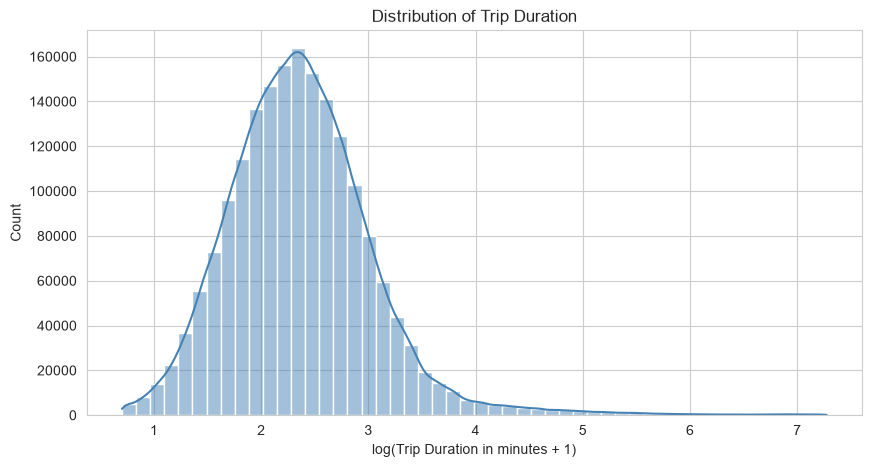

In [16]:
plt.figure(figsize=(10,5))
sns.histplot(np.log1p(df['duration_min']), bins=50, kde=True, color='steelblue')
plt.xlabel('log(Trip Duration in minutes + 1)')
plt.title('Distribution of Trip Duration')
plt.show()

##### 1. Why did you pick the specific chart?
Trip duration is a continuous variable with heavy right-skew (a few very long trips). A histogram is the standard way to see a single variable's distribution shape. Log-transform was applied so the plot isn't crushed by extreme outliers.

##### 2. What is/are the insight(s) found from the chart?
The distribution is roughly bell-shaped (mountain-like) after log-transform, meaning most trips cluster around a typical short duration, with a long tail of much longer/shorter trips.

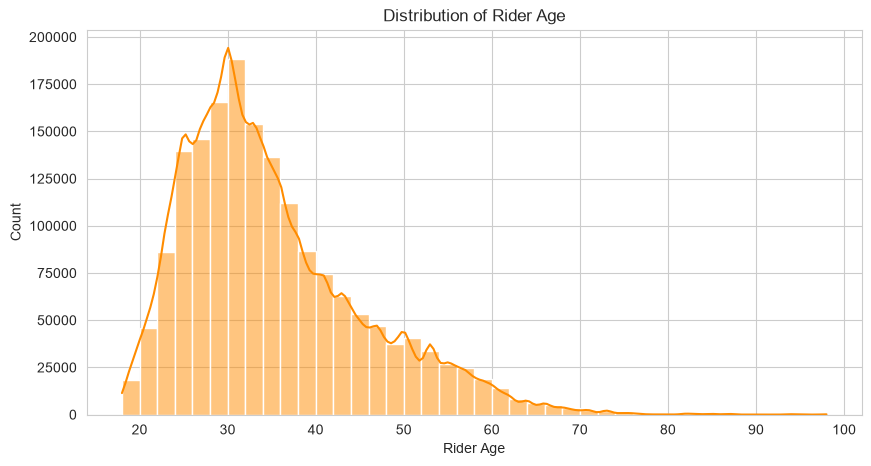

In [17]:
plt.figure(figsize=(10,5))
sns.histplot(df['age'].dropna(), bins=40, color='darkorange', kde=True)
plt.xlabel('Rider Age')
plt.title('Distribution of Rider Age')
plt.show()

##### 1. Why did you pick the specific chart?
Age is a continuous demographic variable, so a histogram best reveals its central tendency and spread.

##### 2. What is/are the insight(s) found from the chart?
The rider base is heavily concentrated in the 25-40 age range, peaking sharply around age 30, with very few riders above 60. This shows the service mainly attracts working-age young adults rather than older or much younger demographics.

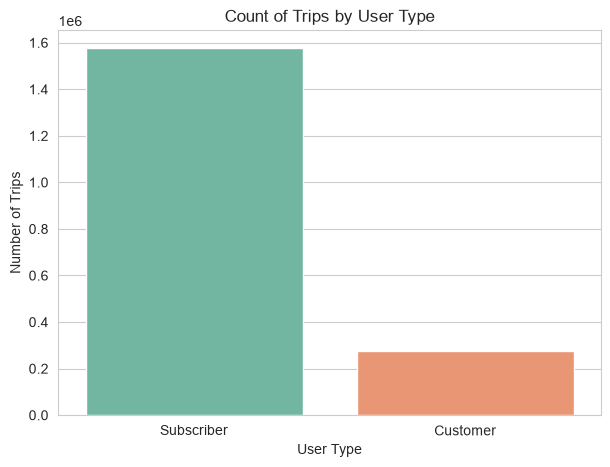

user_type
Subscriber    85.0
Customer      15.0
Name: proportion, dtype: float64

In [18]:
plt.figure(figsize=(7,5))
order = df['user_type'].value_counts().index
sns.countplot(data=df, x='user_type', order=order, hue='user_type', palette='Set2', legend=False)
plt.title('Count of Trips by User Type')
plt.xlabel('User Type')
plt.ylabel('Number of Trips')
plt.show()

df['user_type'].value_counts(normalize=True).mul(100).round(1)

##### 1. Why did you pick the specific chart?
`user_type` is a categorical variable with only 2 levels (Subscriber, Customer) — a count/bar plot is the clearest way to compare their frequencies.

##### 2. What is/are the insight(s) found from the chart?
Subscribers make up the large majority of trips, while Customers (casual riders) are a much smaller share. The system is primarily used by regular/commute members rather than one-time or casual riders.

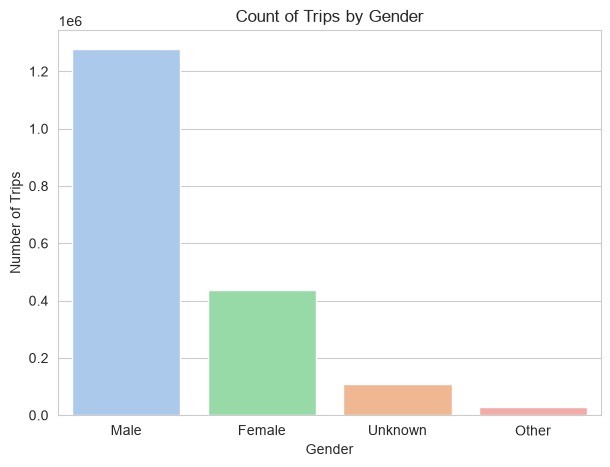

In [19]:
plt.figure(figsize=(7,5))
order = df['member_gender'].value_counts().index
sns.countplot(data=df, x='member_gender', order=order, hue='member_gender', palette='pastel', legend=False)
plt.title('Count of Trips by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Trips')
plt.show()

##### 1. Why did you pick the specific chart?
Gender is a categorical variable with a few levels, so a bar/count plot clearly compares group sizes.

##### 2. What is/are the insight(s) found from the chart?
The majority of riders identify as Male, followed by Female, with smaller shares identifying as Other or Unknown (missing data). The subscriber base skews strongly male.

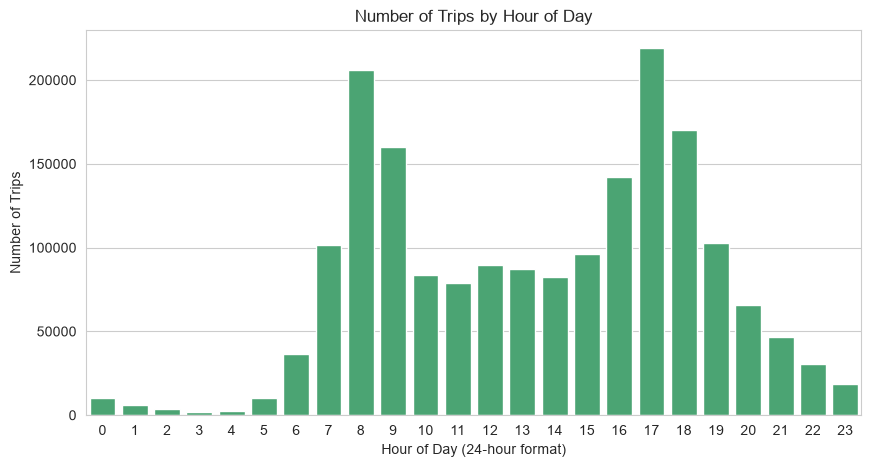

In [20]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='start_hour', color='mediumseagreen')
plt.title('Number of Trips by Hour of Day')
plt.xlabel('Hour of Day (24-hour format)')
plt.ylabel('Number of Trips')
plt.show()

##### 1. Why did you pick the specific chart?
`start_hour` represents time-of-day usage as a single variable; a count plot across hours shows the overall daily demand pattern.

##### 2. What is/are the insight(s) found from the chart?
There are two clear peaks — around 8 AM and 5-6 PM — matching typical commute hours, suggesting the system is heavily used for work commuting rather than leisure riding.

## Bivariate Analysis (5 Charts)

Ab hum do variables ka relationship dekhenge (jaise duration vs season, duration vs user type, etc.) — is section mein "why" aur "insight" har chart ke saath likhenge.

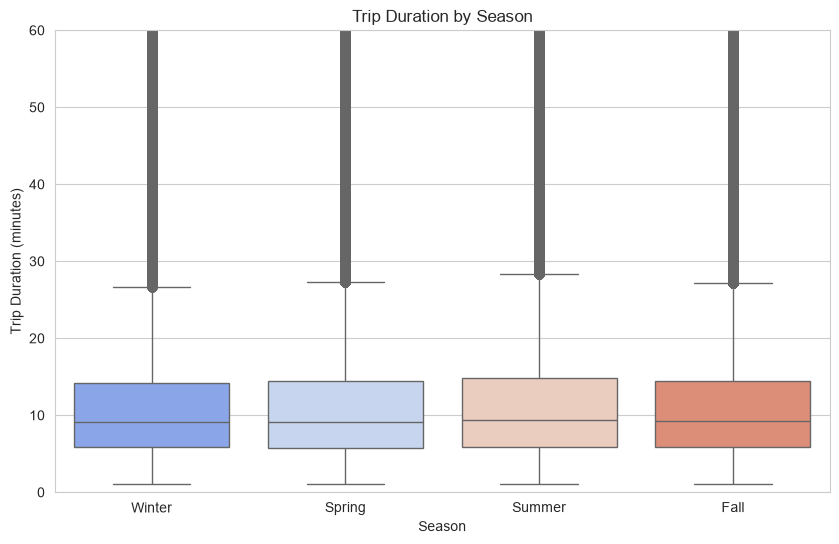

In [21]:
plt.figure(figsize=(10,6))
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
sns.boxplot(data=df, x='season', y='duration_min', order=season_order, hue='season', palette='coolwarm', legend=False)
plt.ylim(0, 60)
plt.title('Trip Duration by Season')
plt.xlabel('Season')
plt.ylabel('Trip Duration (minutes)')
plt.show()

##### 1. Why did you pick the specific chart?
Season is categorical and duration is continuous — a box plot is the standard way to compare a continuous variable's distribution (median, spread, outliers) across categories.

##### 2. What is/are the insight(s) found from the chart?
Trip duration is remarkably consistent across all four seasons (median ~9 minutes in each), showing that weather/season has little to no effect on how long people ride. This suggests trip duration is driven more by trip purpose (commute vs leisure) than by weather conditions.

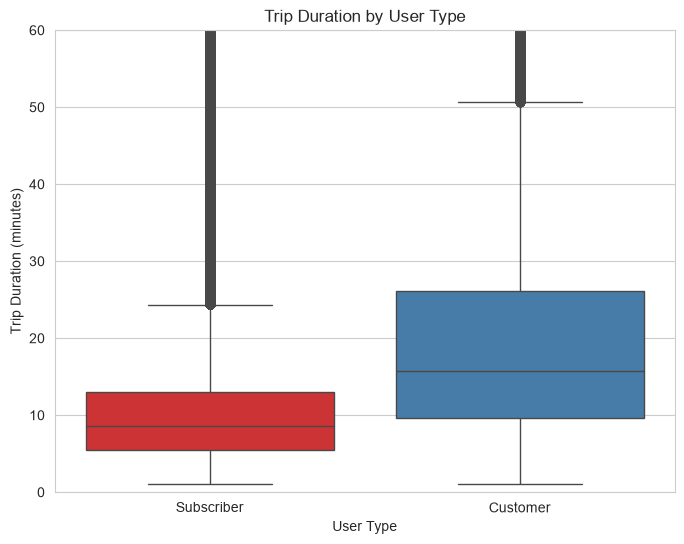

In [22]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='user_type', y='duration_min', hue='user_type', palette='Set1', legend=False)
plt.ylim(0, 60)
plt.title('Trip Duration by User Type')
plt.xlabel('User Type')
plt.ylabel('Trip Duration (minutes)')
plt.show()

##### 1. Why did you pick the specific chart?
User type is categorical (Subscriber/Customer) and duration is continuous — a box plot compares their distributions side by side.

##### 2. What is/are the insight(s) found from the chart?
Customers (casual riders) tend to have noticeably longer median trip durations than Subscribers. This makes sense — Subscribers use the system for quick daily commutes, while Customers are more likely casual/leisure riders taking longer, less routine trips.

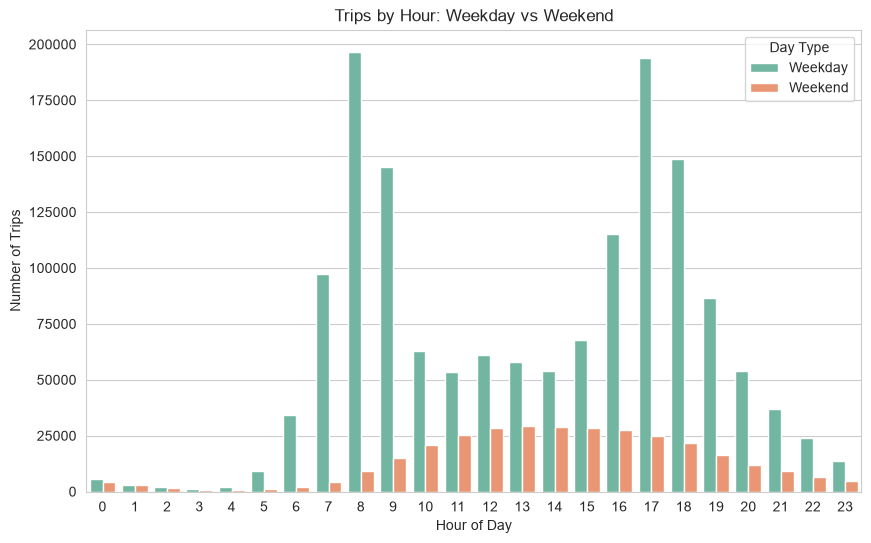

In [23]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='start_hour', hue='day_type', palette='Set2')
plt.title('Trips by Hour: Weekday vs Weekend')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.legend(title='Day Type')
plt.show()

##### 1. Why did you pick the specific chart?
Both `start_hour` and `day_type` matter together here — a grouped count plot (hue) lets us compare the hourly pattern between weekdays and weekends in one view.

##### 2. What is/are the insight(s) found from the chart?
Weekdays show sharp double peaks around 8 AM and 5-6 PM (commute pattern), while weekends show a flatter, single broad peak around midday — confirming Subscribers mostly commute on weekdays, while weekend usage is more leisure-driven and spread out.

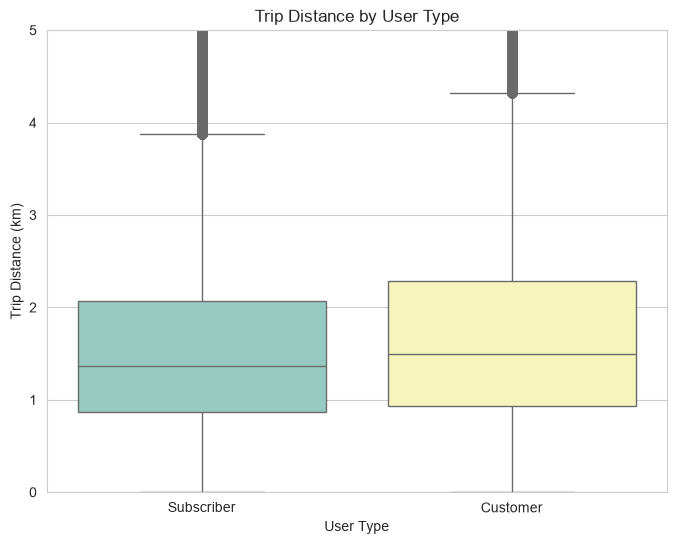

In [24]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='user_type', y='trip_distance_km', hue='user_type', palette='Set3', legend=False)
plt.ylim(0, 5)
plt.title('Trip Distance by User Type')
plt.xlabel('User Type')
plt.ylabel('Trip Distance (km)')
plt.show()

##### 1. Why did you pick the specific chart?
User type is categorical and trip distance is continuous — a box plot compares the distance distribution between Subscribers and Customers.

##### 2. What is/are the insight(s) found from the chart?
Customers show a slightly higher median trip distance (~1.5 km) and wider spread compared to Subscribers (~1.37 km). This aligns with the duration finding — Customers take longer, more varied trips (likely leisure/tourism), while Subscribers take shorter, more consistent commute-distance trips.

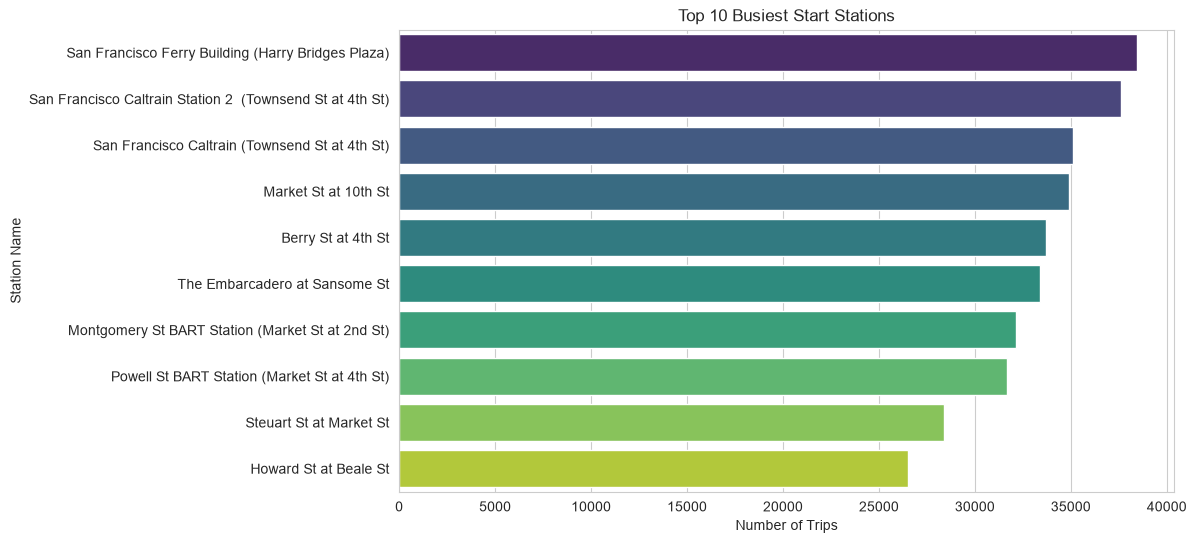

In [25]:
plt.figure(figsize=(10,6))
top_stations = df['start_station_name'].value_counts().head(10)
sns.barplot(x=top_stations.values, y=top_stations.index, hue=top_stations.index, palette='viridis', legend=False)
plt.title('Top 10 Busiest Start Stations')
plt.xlabel('Number of Trips')
plt.ylabel('Station Name')
plt.show()

##### 1. Why did you pick the specific chart?
Comparing trip counts across many station names (a categorical variable with high cardinality) is best done with a horizontal bar chart — it's easy to read station names and compare their trip volumes side by side.

##### 2. What is/are the insight(s) found from the chart?
The busiest station is San Francisco Ferry Building (Harry Bridges Plaza), followed closely by Caltrain-area stations (Townsend St at 4th St) and Market Street stations. Most top stations cluster around San Francisco's Financial District and transit hubs (Caltrain, BART) — reinforcing that GoBike is heavily used to connect commuters to/from major transit stations.

## Multivariate Analysis (5+ Charts)

In this section, we look at 3 or more variables together to uncover deeper, combined patterns that univariate and bivariate analysis alone cannot reveal.

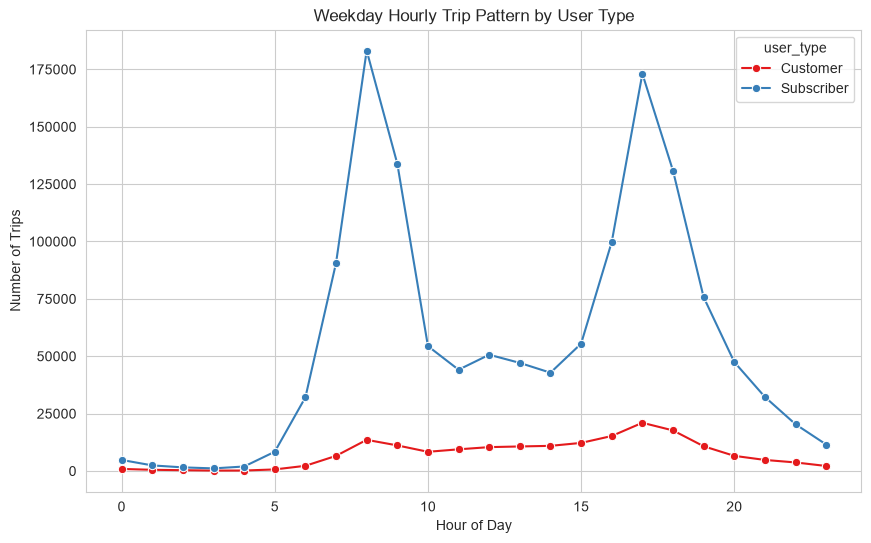

In [26]:
weekday_df = df[df['day_type'] == 'Weekday']
hourly_counts = weekday_df.groupby(['start_hour', 'user_type']).size().reset_index(name='trip_count')

plt.figure(figsize=(10,6))
sns.lineplot(data=hourly_counts, x='start_hour', y='trip_count', hue='user_type', palette='Set1', marker='o')
plt.title('Weekday Hourly Trip Pattern by User Type')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.show()

##### 1. Why did you pick the specific chart?
This combines three variables — hour, user type, and trip count — so a multi-line plot (one line per user type) shows how the commute pattern differs between the two groups across the day.

##### 2. What is/are the insight(s) found from the chart?
Subscribers show a very sharp commute pattern with two distinct peaks at 8 AM and 5-6 PM, confirming they use GoBike primarily to get to/from work. Customers show a much flatter curve with no sharp commute peaks, gradually rising through the afternoon — consistent with casual/leisure use rather than routine commuting.

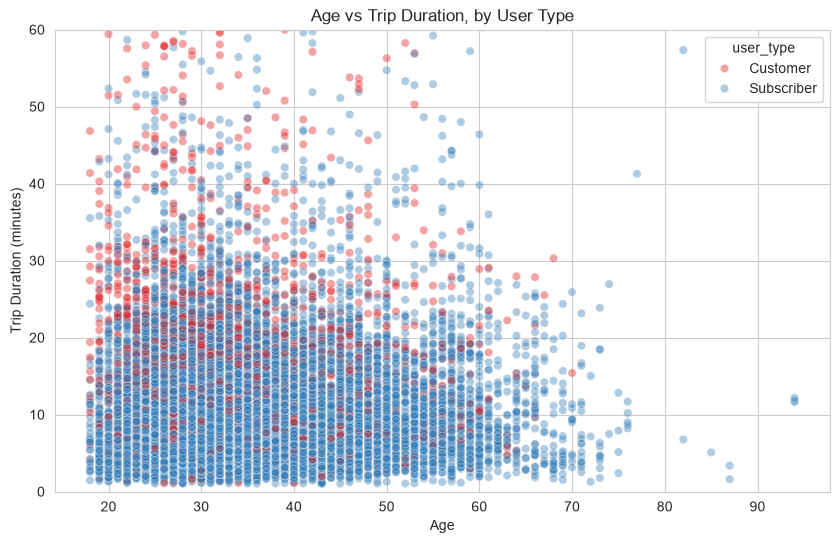

In [27]:
plt.figure(figsize=(10,6))
sample_df = df.sample(20000, random_state=42)  # sampling for a readable scatter plot
sns.scatterplot(data=sample_df, x='age', y='duration_min', hue='user_type', alpha=0.4, palette='Set1')
plt.ylim(0, 60)
plt.title('Age vs Trip Duration, by User Type')
plt.xlabel('Age')
plt.ylabel('Trip Duration (minutes)')
plt.show()

##### 1. Why did you pick the specific chart?
Age and duration are both continuous, and user_type adds a third categorical dimension — a scatter plot with color-coded hue is the standard way to explore relationships between two continuous variables split by a category.

##### 2. What is/are the insight(s) found from the chart?
There is no strong linear relationship between age and trip duration — riders of all ages take both short and long trips. However, Subscriber trips (blue) are heavily concentrated in the 20-45 age range, while Customer trips (red), though fewer, are relatively more spread across a wider age range, including older riders (60+).

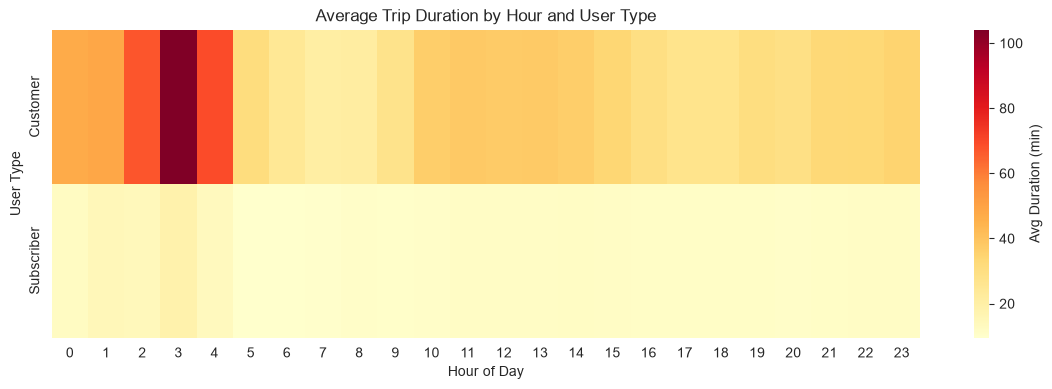

In [28]:
pivot_data = df.pivot_table(values='duration_min', index='user_type', columns='start_hour', aggfunc='mean')

plt.figure(figsize=(14,4))
sns.heatmap(pivot_data, cmap='YlOrRd', annot=False, cbar_kws={'label': 'Avg Duration (min)'})
plt.title('Average Trip Duration by Hour and User Type')
plt.xlabel('Hour of Day')
plt.ylabel('User Type')
plt.show()

##### 1. Why did you pick the specific chart?
Combining hour, user type, and average duration together works best as a heatmap — it shows the full pattern across a hour x user_type grid using color intensity, easier to scan than multiple separate charts.

##### 2. What is/are the insight(s) found from the chart?
Subscriber trip durations stay consistently short (light color) across all hours of the day, reinforcing their commute-driven, quick-trip usage pattern. Customers show a sharp average-duration spike around 2-4 AM — likely due to a small number of very long overnight trips (outliers) skewing the average during low-volume hours, rather than a genuine usage pattern.

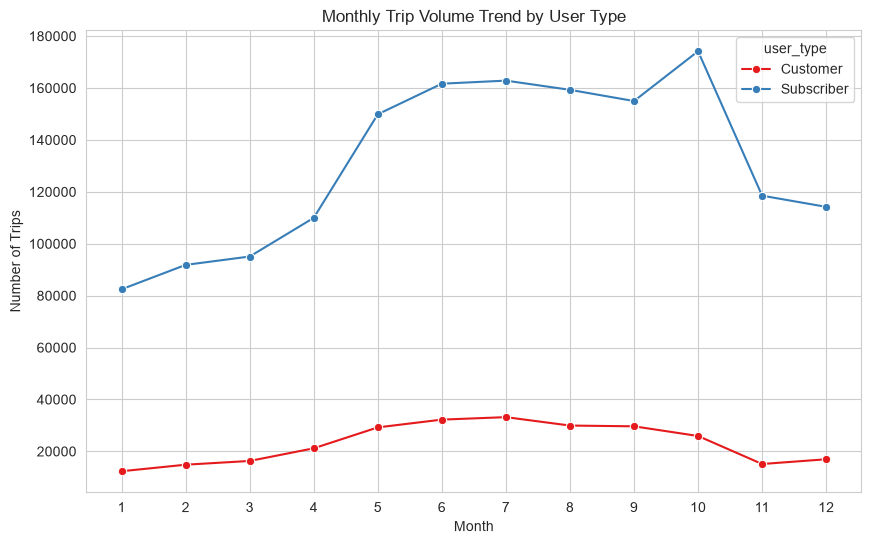

In [29]:
monthly_counts = df.groupby(['start_month', 'user_type']).size().reset_index(name='trip_count')

plt.figure(figsize=(10,6))
sns.lineplot(data=monthly_counts, x='start_month', y='trip_count', hue='user_type', palette='Set1', marker='o')
plt.title('Monthly Trip Volume Trend by User Type')
plt.xlabel('Month')
plt.ylabel('Number of Trips')
plt.xticks(range(1,13))
plt.show()

##### 1. Why did you pick the specific chart?
Month, user type, and trip volume together — a multi-line plot over time (one line per user type) reveals seasonal usage trends and whether both groups follow the same pattern.

##### 2. What is/are the insight(s) found from the chart?
Both user types show a rising trend from winter into fall, with Subscriber volume peaking sharply in October before a steep drop in November (likely due to weather turning colder/wetter). Customer volume follows a similar but much smaller-scale pattern, peaking around June-July (summer, likely tourist season) rather than October — suggesting Customers ride more for leisure/tourism reasons tied to pleasant weather, while Subscribers' commute-driven usage is less weather-sensitive until it gets notably worse.

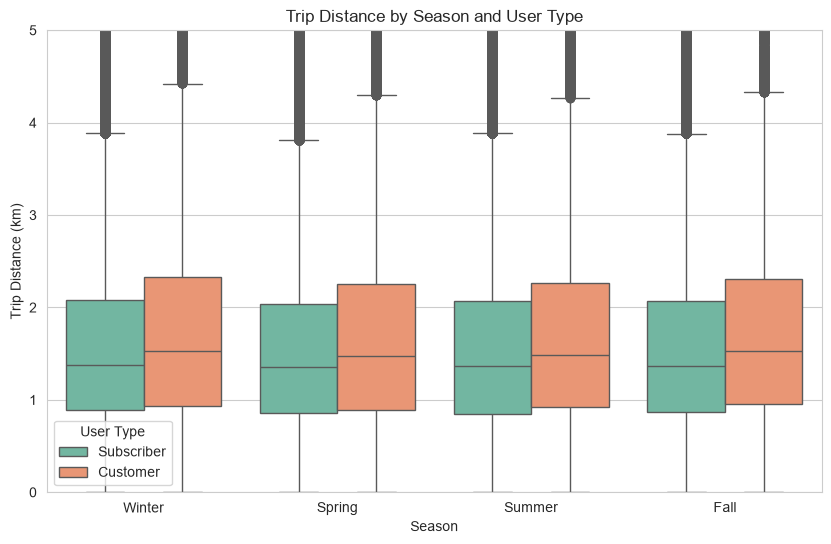

In [30]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='season', y='trip_distance_km', hue='user_type', 
            order=['Winter','Spring','Summer','Fall'], palette='Set2')
plt.ylim(0, 5)
plt.title('Trip Distance by Season and User Type')
plt.xlabel('Season')
plt.ylabel('Trip Distance (km)')
plt.legend(title='User Type')
plt.show()

##### 1. Why did you pick the specific chart?
Season, user type, and trip distance together — a grouped box plot shows whether the Subscriber-vs-Customer distance gap (seen earlier) holds consistently across all seasons, or changes with weather.

##### 2. What is/are the insight(s) found from the chart?
The gap between Customer and Subscriber trip distances stays consistent across all four seasons — Customers ride slightly farther than Subscribers regardless of season. This confirms user type (commute vs leisure behavior), not season/weather, is the main driver of trip distance differences.

## 5. Business Recommendations


Based on the complete analysis above, here are the key business recommendations for Ford GoBike:

1. **Optimize station rebalancing around commute hours** — Since usage sharply peaks at 8 AM and 5-6 PM on weekdays (driven almost entirely by Subscribers), the operations team should prioritize redistributing bikes to high-demand stations (like San Francisco Ferry Building, Caltrain, and Financial District stations) just before these peak windows.

2. **Design a dedicated weekend/leisure pass for Customers** — Customers ride less frequently but take longer, farther trips, mostly spread through midday on weekends. A day-pass or weekend-bundle pricing plan tailored to casual/tourist riders could increase Customer conversion and revenue, since their usage pattern is fundamentally different from commuting Subscribers.

3. **Target subscription marketing at the 25-40 age group** — This is both the largest rider segment and the core Subscriber base. Marketing campaigns (referral discounts, workplace partnerships) aimed at this demographic are likely to have the highest conversion, since they already represent proven regular usage.

4. **Investigate and address the seasonal Subscriber drop after October** — Subscriber volume falls sharply in November, likely due to weather. The business could explore weather-protected bike designs, covered docking stations, or off-season discounted plans to reduce this drop-off and retain ridership through colder months.

5. **Review and clean anomalous data at the source** — A small number of extreme outliers (24-hour trips, 65 km distances, and birth years like 1881) suggest either faulty GPS/station logging or unreturned bikes. Fixing this at the data-collection level (e.g., auto-flagging trips beyond a reasonable duration/distance threshold) will improve both future analysis accuracy and potentially reduce lost/stolen bike costs.

## 6. Conclusion

This EDA on 12 months of Ford GoBike trip data (1.85 million cleaned trip records) revealed clear, distinct usage patterns between the two rider segments:

- **Subscribers** (~85% of trips) are commute-driven: short, consistent trip durations, sharp weekday peaks at 8 AM and 5-6 PM, concentrated in the 25-40 age range, and heavy usage of stations near transit hubs (Ferry Building, Caltrain, BART stations).
- **Customers** (~15% of trips) are more leisure/tourism-driven: longer and farther trips on average, flatter usage spread through the day (especially weekends), and a wider age range of riders.
- Seasonal effects exist but are moderate — overall volume rises through the year and drops sharply after October, while trip duration and distance patterns stay fairly stable across seasons.

These findings suggest Ford GoBike's business strategy should treat Subscribers and Customers as two distinct customer segments with different needs — commute reliability and station availability for Subscribers, and flexible leisure-oriented pricing for Customers.